# 预处理

In [1]:
!whoami

luke\41507


In [2]:
!pwd

/d/BaiduSyncdisk/python_code/python_code2026/day25/chapter_6


In [3]:
import os
from tensorflow.keras.datasets import imdb

#数据默认下载路径在 C:\Users\41507\.keras\datasets
# mac电脑  /Users/你的用户名/.keras/datasets/
# Linux /home/用户名/.keras/datasets/
# Linux阿里云  !cp file1 file2 /home/用户名/.keras/datasets/


# 加载前1万个词构成的数据集，index_from=3, 数据下载到data文件夹,词典默认大小是88582
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words, index_from=3)
print(type(x_train))
print(x_train.shape)
print(x_test.shape)
# 查看第一个样本
print("第一个训练样本：", x_train[0])
print("标签：", y_train[0:10])

# 加载imdb词典
word_index = imdb.get_word_index()
# imdb的字典是单词到索引的映射，索引要加3，0/1/2分别是padding, start, 未知符号
word_index = {word: idx + 3 for word, idx in word_index.items()}  # 0,1,2,3空出来做别的事,这里的idx是从1开始的,所以加3
word_index.update({
    "[PAD]": 0,  # 填充 token
    "[BOS]": 1,  # begin of sentence
    "[UNK]": 2,  # 未知 token
    "[EOS]": 3,  # end of sentence
})

print(x_train[1])


<class 'numpy.ndarray'>
(25000,)
(25000,)
第一个训练样本： [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
标签： [1 0 

In [4]:
word_index['hi']

6596

In [5]:
# 构建索引到词的词典
index_to_word = {idx: word for word, idx in word_index.items()}

# 编写decode_review函数
def decode_review(encoded_review):
    return ' '.join([index_to_word.get(idx, '?') for idx in encoded_review])

# 测试decode_review函数，查看第一个训练样本原始文本内容
print("解码后的第一个训练样本：")
print(decode_review(x_train[0]))


解码后的第一个训练样本：
[BOS] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and now the same being director [UNK] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [UNK] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [UNK] to the two little boy's that played the [UNK] of norman and paul they were just brilliant children are often left out of the [UNK] list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be prai

In [6]:
import numpy as np

#如何将ndarray存入磁盘及读取
# 将训练和测试数据保存到磁盘
# np.save('x_train.npy', x_train, allow_pickle=True)
# np.save('y_train.npy', y_train, allow_pickle=True)
# np.save('x_test.npy', x_test, allow_pickle=True)
# np.save('y_test.npy', y_test, allow_pickle=True)

# # 从磁盘读取保存的数据
# x_train_loaded = np.load('x_train.npy', allow_pickle=True)
# y_train_loaded = np.load('y_train.npy', allow_pickle=True)
# x_test_loaded = np.load('x_test.npy', allow_pickle=True)
# y_test_loaded = np.load('y_test.npy', allow_pickle=True)

# print('x_train_loaded shape:', x_train_loaded.shape)
# print('y_train_loaded shape:', y_train_loaded.shape)
# print('x_test_loaded shape:', x_test_loaded.shape)
# print('y_test_loaded shape:', y_test_loaded.shape)


In [7]:
# 将测试集划分为验证集和测试集
# 从原始测试集中取前10000个样本作为验证集
x_val = x_test[:10000]
y_val = y_test[:10000]

# 剩余的15000个样本作为测试集
x_test = x_test[10000:]
y_test = y_test[10000:]

print(f"验证集样本数: {len(x_val)}")
print(f"测试集样本数: {len(x_test)}")
print(f"验证集标签示例: {y_val[:10]}")
print(f"测试集标签示例: {y_test[:10]}")

验证集样本数: 10000
测试集样本数: 15000
验证集标签示例: [0 1 1 0 1 1 1 0 0 1]
测试集标签示例: [1 1 0 1 0 0 1 0 1 1]


## 通过直方图来观察样本长度分布

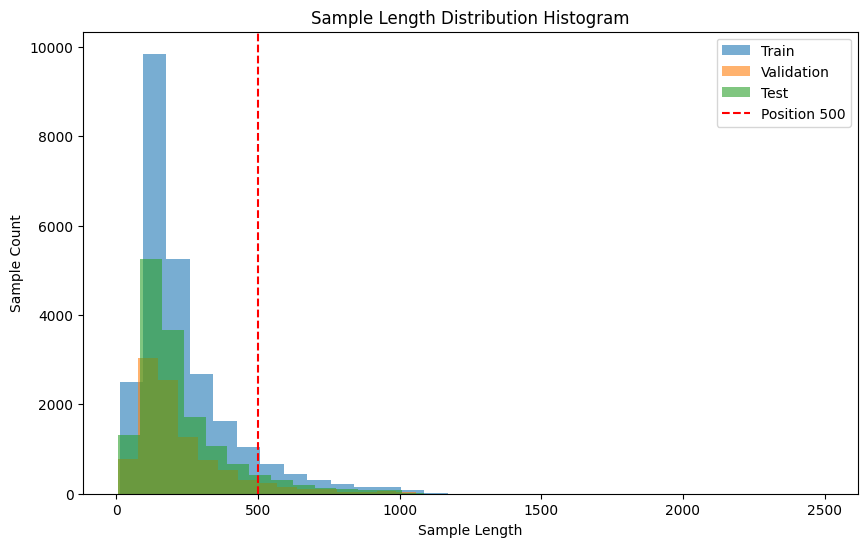

In [8]:
import matplotlib.pyplot as plt

# Calculate sample lengths
train_lengths = [len(seq) for seq in x_train]
val_lengths = [len(seq) for seq in x_val]
test_lengths = [len(seq) for seq in x_test]

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=30, alpha=0.6, label='Train')
plt.hist(val_lengths, bins=30, alpha=0.6, label='Validation')
plt.hist(test_lengths, bins=30, alpha=0.6, label='Test')
plt.axvline(x=500, color='r', linestyle='--', label='Position 500')
plt.xlabel('Sample Length')
plt.ylabel('Sample Count')
plt.title('Sample Length Distribution Histogram')
plt.legend()
plt.show()


# Tokenizer

In [9]:
from unittest import result


class Tokenizer:
    def __init__(self, word_index, index_to_word):
        """
        word_index: dict, 词 --> id，对应于词典
        index_to_word: dict, id --> 词，对应于词典
        """
        self.word_index = word_index
        self.index_to_word = index_to_word
        self.vocab_size = len(word_index)

        # Special tokens
        # 参照@01_embedding_padding_pooling.ipynb (21-24):
        # "[PAD]": 0,  # 填充 token
        # "[BOS]": 1,  # begin of sentence
        # "[UNK]": 2,  # 未知 token
        # "[EOS]": 3,  # end of sentence
        self.pad_token = "[PAD]"
        self.bos_token = "[BOS]"
        self.unk_token = "[UNK]"
        self.eos_token = "[EOS]"
        self.pad_id = self.word_index[self.pad_token]
        self.bos_id = self.word_index[self.bos_token]
        self.unk_id = self.word_index[self.unk_token]
        self.eos_id = self.word_index[self.eos_token]

    def encode(self, text, maxlen=None, padding='post', truncating='post',
               add_bos=False, add_eos=False):
        """
        参数:
            text: 列表，其中每个元素为长字符串（批量编码）
            maxlen: int 或 None，指定最大长度
            padding: 'pre' 或 'post'
            truncating: 'pre' 或 'post'
            add_bos: 是否加开始符（[BOS]）
            add_eos: 是否加结束符（[EOS]）
        返回: List[List[int]] ，每个样本的id序列
        """
        if not isinstance(text, list):
            raise ValueError("输入text应为字符串列表")

        # 计算需要的序列长度
        batch_max_len = max([len(seq) for seq in text]) #batch内最长序列长度
        if add_bos:
            batch_max_len += 1
        if add_eos:
            batch_max_len += 1

        # 如果maxlen为None或者batch内最大长度小于maxlen，使用batch内最大长度
        if maxlen is None or batch_max_len < maxlen:
            maxlen = batch_max_len

        result=[]
        for text in text:
            sequence = []

            # 添加开始标记
            if add_bos:
                sequence.append(self.bos_id)

            # 将词转换为索引
            for word in text:
                sequence.append(self.word_index.get(word, self.unk_id))

            # 添加结束标记
            if add_eos:
                sequence.append(self.eos_id)

            # 截断序列
            if len(sequence) > maxlen:
                if truncating == 'pre':
                    sequence = sequence[-maxlen:]
                else:  # truncating == 'post'
                    sequence = sequence[:maxlen]
            else:
                # 填充序列
                pad_length = maxlen - len(sequence)
                if pad_length > 0:
                    if padding == 'pre':
                        sequence = [self.pad_id] * pad_length + sequence
                    else:  # padding == 'post'
                        sequence = sequence + [self.pad_id] * pad_length

            result.append(sequence)

        return np.array(result)

    def decode(self, ids, remove_special=True):
        """
        参数:
            ids: 二维int列表
            remove_special: 是否移除特殊符号
        返回: 列表，每个元素是一条字符串（tokens拼接）
        """
        results = []
        special_tokens = {self.pad_token, self.bos_token, self.eos_token}  # 特殊符号集合
        for seq in ids:  # 遍历每个序列
            tokens = []
            for idx in seq:
                token = self.index_to_word.get(idx, self.unk_token)
                if remove_special and token in special_tokens: #默认移除pad，bos，eos
                    continue
                tokens.append(token)
            results.append(' '.join(tokens))

        return results


In [10]:
raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
raw_text

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

In [11]:
index_to_word[4825]

'hello'

In [12]:
tokenizer=Tokenizer(word_index,index_to_word)
encoded_text = tokenizer.encode(raw_text)
print(encoded_text)
decoded_text = tokenizer.decode(encoded_text)
print(decoded_text)


[[ 4825   182     0     0     0]
 [    2  3004     2    19 19233]
 [   14     9     6  2181     0]]
['hello world', '[UNK] text [UNK] with batch', 'this is a test']


# Dataset和DataLoader

In [13]:
a,b=zip(('a',1),('b',1),('c',0))
print(a)
print(b)


('a', 'b', 'c')
(1, 1, 0)


In [14]:
from torch.utils.data import Dataset, DataLoader
import torch
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        """
        参数:
            texts: 原始文本数据，列表形式，每个元素是一个句子的token列表
            labels: 标签数据，列表形式
        """
        self.texts = tokenizer.decode(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch,max_len=500):
    """
    DataLoader的collate_fn，对批次数据进行编码和填充
    参数:
        batch: 一个批次的原始文本数据和标签
    返回:
        编码后的tensor和标签tensor
    """
    texts, labels = zip(*batch)
    # 先将每个文本字符串split成token列表
    token_lists = [text.split() for text in texts]
    # 使用tokenizer对批次数据进行编码
    encoded_batch = tokenizer.encode(token_lists,maxlen=max_len,padding='pre', add_bos=False, add_eos=True)
    return torch.tensor(encoded_batch, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# 创建训练集DataLoader
train_dataset = TextDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

# 创建验证集DataLoader
val_dataset = TextDataset(x_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# 创建测试集DataLoader
test_dataset = TextDataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# 测试训练集DataLoader
print("Training DataLoader:")
for batch_texts, batch_labels in train_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    print("Batch content:")
    print(batch_texts)
    print("Batch labels:")
    print(batch_labels)
    print("Decoded batch:")
    decoded_batch = tokenizer.decode(batch_texts.tolist())
    print(decoded_batch)
    break  # 只显示第一个batch

print("-" * 50)
print("Validation DataLoader:")
for batch_texts, batch_labels in val_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch

print("-" * 50)
print("Test DataLoader:")
for batch_texts, batch_labels in test_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch


Training DataLoader:
Batch texts shape: torch.Size([64, 500])
Batch labels shape: torch.Size([64])
Batch content:
tensor([[   0,    0,    0,  ...,  434,   62,    3],
        [   0,    0,    0,  ...,   41, 1461,    3],
        [   0,    0,    0,  ..., 1184,    2,    3],
        ...,
        [   0,    0,    0,  ...,   80,   30,    3],
        [   0,    0,    0,  ..., 2161,  480,    3],
        [   0,    0,    0,  ...,    9,   23,    3]])
Batch labels:
tensor([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
        1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1])
Decoded batch:
['i love anthony hopkins as an actor so i was very interested to see how he would do as a writer director i could not have been more disappointed by this move the movie was so disjointed and the cinematography was so over done to the point i wanted to pull the plug out of the wall the actors were very good but it

# 搭建分类模型

In [16]:
import torch
import torch.nn as nn

class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=1, bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.bidirectional = bidirectional
        self.rnn = nn.RNN(
            input_size=embedding_dim,      # 输入特征维度
            hidden_size=hidden_dim,        # 隐状态向量的维度
            num_layers=rnn_layers,         # RNN层数
            batch_first=True,              # (batch, seq, feature)
            nonlinearity='tanh',           # 激活函数
            bidirectional=bidirectional    # 是否双向
        )
        rnn_output_dim = hidden_dim * (2 if bidirectional else 1)
        # 2层线性
        self.fc1 = nn.Linear(rnn_output_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        '''
        x: LongTensor, shape (batch_size, seq_len)
        '''
        embed = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        output, h_n = self.rnn(embed)  # output: (batch, seq_len, hidden_dim*num_directions), h_n: (num_layers*num_directions, batch, hidden_dim)
        print("RNN output shape:", output.shape)
        print("RNN h_n shape:", h_n.shape)
        # 获取最后一层（和每个方向）的hidden
        if self.bidirectional:
            # h_n shape: (num_layers*2, batch, hidden_dim)
            # 取最后一层的两个方向的hidden，然后拼起来
            last_layer_h_n = h_n[-2:,:,:]   # shape: (2, batch, hidden_dim)
            last_hidden = torch.cat([last_layer_h_n[0], last_layer_h_n[1]], dim=-1)  # (batch, hidden_dim*2)
        else:
            last_hidden = h_n[-1]  # (batch, hidden_dim)
        out = self.fc1(last_hidden)
        out = self.relu(out)
        out = self.fc2(out)  # (batch, num_classes)
        return out

# 参数举例

vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 1
bidirectional = False

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)


In [14]:
# 编写前向计算验证模型
# 假设有一个 batch 输入张量（随机生成，并假设最大长度为 10）
batch_size = 2
seq_len = 10
x = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
print(x.shape)
with torch.no_grad():
    outputs = model(x)
    print("Output shape:", outputs.shape)
    print("Output:", outputs)


torch.Size([2, 10])
Output shape: torch.Size([2, 1])
Output: tensor([[-0.0924],
        [ 0.0687]])


In [15]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 1024
rnn.weight_hh_l0: 4096
rnn.bias_ih_l0: 64
rnn.bias_hh_l0: 64
fc1.weight: 4096
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 169473


In [16]:
64*64

4096

# 训练

In [17]:
len(train_dataloader)

391

In [18]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
)

# 开始训练
trainer.train_binary(num_epochs=20)


[Step 100] Val Loss: 0.6897 Val Acc: 0.5348
[Step 200] Val Loss: 0.6858 Val Acc: 0.5502
[Step 300] Val Loss: 0.6875 Val Acc: 0.5434
Epoch [1/20] Train Loss: 0.6863 Acc: 0.5406 | Val Loss: 0.6875 Val Acc: 0.5434
[Step 400] Val Loss: 0.6740 Val Acc: 0.5789
[Step 500] Val Loss: 0.6652 Val Acc: 0.5906
[Step 600] Val Loss: 0.6502 Val Acc: 0.6203
[Step 700] Val Loss: 0.6909 Val Acc: 0.5245
Epoch [2/20] Train Loss: 0.6688 Acc: 0.5794 | Val Loss: 0.6909 Val Acc: 0.5245
[Step 800] Val Loss: 0.6792 Val Acc: 0.5604
[Step 900] Val Loss: 0.6877 Val Acc: 0.5508
[Step 1000] Val Loss: 0.6366 Val Acc: 0.6412
[Step 1100] Val Loss: 0.6633 Val Acc: 0.5970
Epoch [3/20] Train Loss: 0.6664 Acc: 0.5844 | Val Loss: 0.6633 Val Acc: 0.5970
[Step 1200] Val Loss: 0.6908 Val Acc: 0.5262
[Step 1300] Val Loss: 0.6894 Val Acc: 0.5146
[Step 1400] Val Loss: 0.6844 Val Acc: 0.5609
[Step 1500] Val Loss: 0.6777 Val Acc: 0.5654
Epoch [4/20] Train Loss: 0.6836 Acc: 0.5523 | Val Loss: 0.6777 Val Acc: 0.5654
[Step 1600] Val Lo

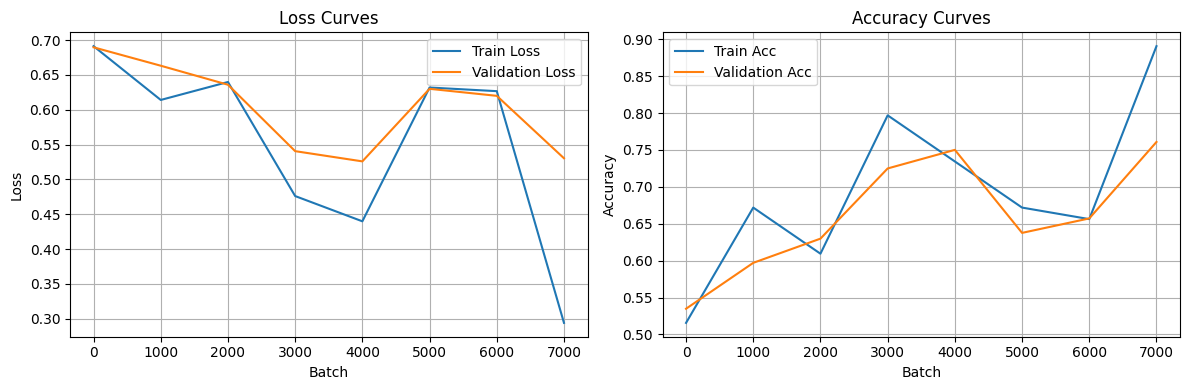

In [19]:
trainer.plot_curves()

# 双向RNN

In [23]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 1
bidirectional = True

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)

[Step 100] Val Loss: 0.6922 Val Acc: 0.5198
[Step 200] Val Loss: 0.6890 Val Acc: 0.5359
[Step 300] Val Loss: 0.6842 Val Acc: 0.5506
Epoch [1/20] Train Loss: 0.6889 Acc: 0.5340 | Val Loss: 0.6842 Val Acc: 0.5506
[Step 400] Val Loss: 0.6799 Val Acc: 0.5661
[Step 500] Val Loss: 0.6731 Val Acc: 0.5734
[Step 600] Val Loss: 0.6643 Val Acc: 0.5947
[Step 700] Val Loss: 0.6413 Val Acc: 0.6335
Epoch [2/20] Train Loss: 0.6593 Acc: 0.6007 | Val Loss: 0.6413 Val Acc: 0.6335
[Step 800] Val Loss: 0.6384 Val Acc: 0.6376
[Step 900] Val Loss: 0.6321 Val Acc: 0.6506
[Step 1000] Val Loss: 0.6141 Val Acc: 0.6625
[Step 1100] Val Loss: 0.6755 Val Acc: 0.5589
Epoch [3/20] Train Loss: 0.6452 Acc: 0.6219 | Val Loss: 0.6755 Val Acc: 0.5589
[Step 1200] Val Loss: 0.6461 Val Acc: 0.6177
[Step 1300] Val Loss: 0.6375 Val Acc: 0.6316
[Step 1400] Val Loss: 0.6025 Val Acc: 0.6783
[Step 1500] Val Loss: 0.6036 Val Acc: 0.6831
Epoch [4/20] Train Loss: 0.6079 Acc: 0.6691 | Val Loss: 0.6036 Val Acc: 0.6831
[Step 1600] Val Lo

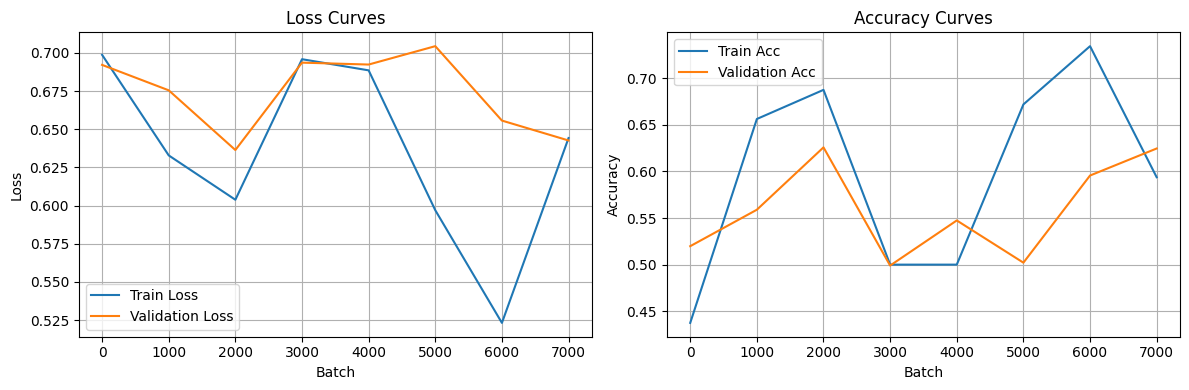

In [24]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
    early_stopping_kwargs=dict(patience=5, min_delta=1e-4, mode='max'),
)

# 开始训练
trainer.train_binary(num_epochs=20)
trainer.plot_curves()

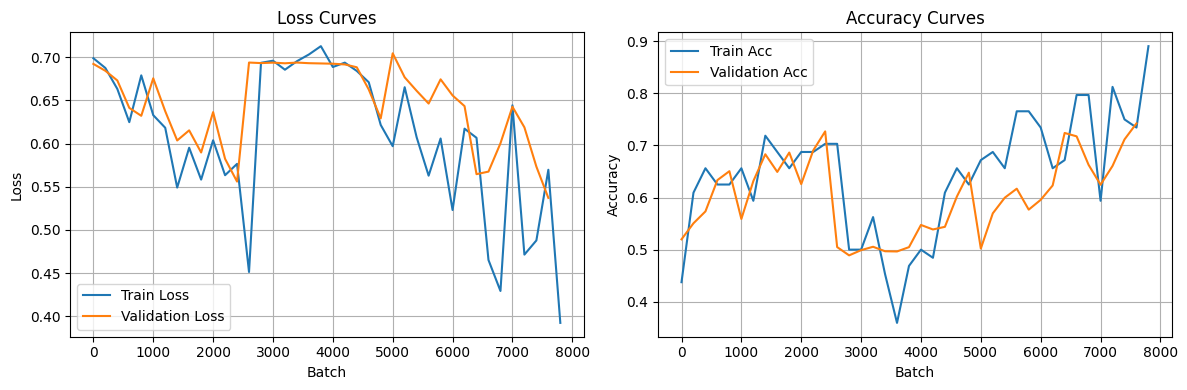

In [25]:
trainer.plot_curves(200)

# 双层单向 RNN

In [21]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 2
bidirectional = False

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 编写前向计算验证模型
# 随便生成一个 batch 的数据进行前向推理，可以用 DataLoader 中的一批
model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        break  # 只跑一批


RNN output shape: torch.Size([64, 500, 64])
RNN h_n shape: torch.Size([2, 64, 64])


In [22]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 1024
rnn.weight_hh_l0: 4096
rnn.bias_ih_l0: 64
rnn.bias_hh_l0: 64
rnn.weight_ih_l1: 4096
rnn.weight_hh_l1: 4096
rnn.bias_ih_l1: 64
rnn.bias_hh_l1: 64
fc1.weight: 4096
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 177793


In [ ]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
    early_stopping_kwargs=dict(patience=3, min_delta=1e-4, mode='max'),
)

# 开始训练
trainer.train_binary(num_epochs=20)
trainer.plot_curves()

# 双层双向RNN

In [23]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 2
bidirectional = True

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 编写前向计算验证模型
# 随便生成一个 batch 的数据进行前向推理，可以用 DataLoader 中的一批
model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        break  # 只跑一批


RNN output shape: torch.Size([64, 500, 128])
RNN h_n shape: torch.Size([4, 64, 64])


In [24]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 1024
rnn.weight_hh_l0: 4096
rnn.bias_ih_l0: 64
rnn.bias_hh_l0: 64
rnn.weight_ih_l0_reverse: 1024
rnn.weight_hh_l0_reverse: 4096
rnn.bias_ih_l0_reverse: 64
rnn.bias_hh_l0_reverse: 64
rnn.weight_ih_l1: 8192
rnn.weight_hh_l1: 4096
rnn.bias_ih_l1: 64
rnn.bias_hh_l1: 64
rnn.weight_ih_l1_reverse: 8192
rnn.weight_hh_l1_reverse: 4096
rnn.bias_ih_l1_reverse: 64
rnn.bias_hh_l1_reverse: 64
fc1.weight: 8192
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 203649


In [25]:
128*64

8192